In [24]:
import sys
sys.path.append("..")                  # let the notebook see the project folder
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_tables

tables = load_tables("../data/raw")
for name, df in tables.items():
    print(name, df.shape)              # should match Day 1's shapesz

telemetry (876100, 6)
errors (3919, 3)
maint (3286, 3)
failures (761, 3)
machines (100, 3)


In [25]:
tel = tables["telemetry"]

assert tel["machineID"].between(1, 100).all(), "machineID outside 1-100"
assert not tel.duplicated(["machineID", "datetime"]).any(), "duplicate machine-hours"

print("Validation checks passed.")

Validation checks passed.


In [26]:
tel["volt"].min()

np.float64(97.333603782359)

In [27]:
tel["rotate"].min()


np.float64(138.432075304341)

In [28]:
tel["pressure"].min()

np.float64(51.2371057734253)

In [29]:
tel["vibration"].min()

np.float64(14.877053998383)

In [30]:
failures = tables["failures"]

In [31]:
failures["failure"].unique()

<StringArray>
['comp4', 'comp1', 'comp2', 'comp3']
Length: 4, dtype: str

In [32]:
failures["failure"].isin(["comp1", "comp2", "comp3", "comp4"])

0      True
1      True
2      True
3      True
4      True
       ... 
756    True
757    True
758    True
759    True
760    True
Name: failure, Length: 761, dtype: bool

In [33]:
tables["errors"]["errorID"]

0       error1
1       error3
2       error5
3       error4
4       error4
         ...  
3914    error2
3915    error1
3916    error2
3917    error3
3918    error3
Name: errorID, Length: 3919, dtype: str

In [34]:
tables["errors"]["errorID"].isin(["error1", "error2", "error3", "error4", "error5"])

0       True
1       True
2       True
3       True
4       True
        ... 
3914    True
3915    True
3916    True
3917    True
3918    True
Name: errorID, Length: 3919, dtype: bool

In [35]:
tables["failures"]["machineID"].unique()

array([  1,   2,   3,   4,   5,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  78,  79,  80,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100])

In [36]:
tables["machines"]["machineID"]

0       1
1       2
2       3
3       4
4       5
     ... 
95     96
96     97
97     98
98     99
99    100
Name: machineID, Length: 100, dtype: int64

In [37]:
tables["failures"]["machineID"].isin(
    tables["machines"]["machineID"]
).all()

np.True_

In [38]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_tables

tables = load_tables("../data/raw")
fail = tables["failures"].copy()
tel = tables["telemetry"]
SENSORS = ["volt", "rotate", "pressure", "vibration"]

failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64


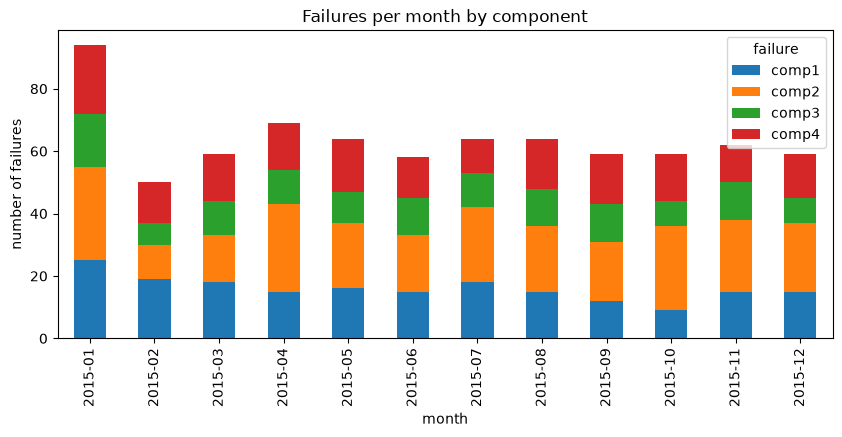

In [39]:
print(fail["failure"].value_counts())

fail["month"] = fail["datetime"].dt.to_period("M")
monthly = fail.groupby(["month", "failure"]).size().unstack(fill_value=0)

monthly.plot(kind="bar", stacked=True, figsize=(10, 4),
             title="Failures per month by component")
plt.ylabel("number of failures")
plt.show()

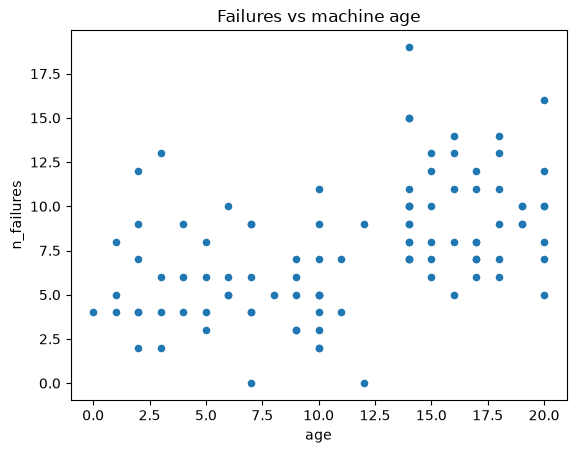

         mean  count
model               
model1  11.81     16
model2   9.88     17
model3   6.31     35
model4   5.72     32
correlation, age vs failures: 0.47


In [40]:
per_machine = fail.groupby("machineID").size().rename("n_failures")

m = (tables["machines"].set_index("machineID")
       .join(per_machine)
       .fillna({"n_failures": 0}))

m.plot(kind="scatter", x="age", y="n_failures", title="Failures vs machine age")
plt.show()

print(m.groupby("model")["n_failures"].agg(["mean", "count"]).round(2))
print("correlation, age vs failures:", round(m["age"].corr(m["n_failures"]), 2))

              datetime  machineID failure    month
2  2015-04-20 06:00:00          1   comp2  2015-04
5  2015-10-17 06:00:00          1   comp2  2015-10
8  2015-03-19 06:00:00          2   comp2  2015-03
9  2015-04-18 06:00:00          2   comp2  2015-04
10 2015-12-29 06:00:00          2   comp2  2015-12


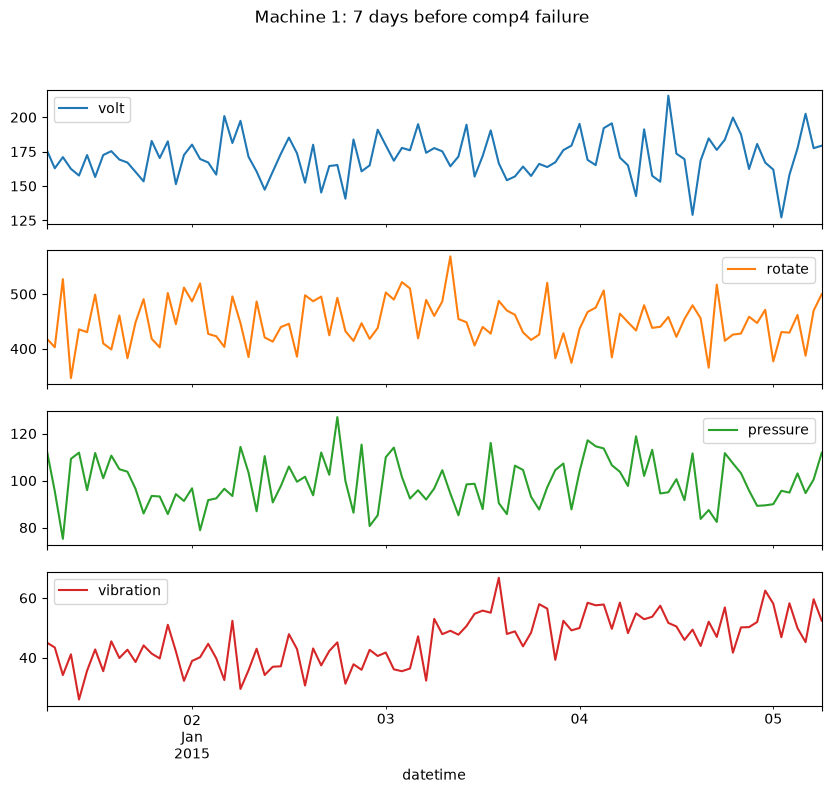

In [41]:
print(fail[fail["failure"] == "comp2"].head())    # find row numbers for a component

f = fail.iloc[0]                                   # change 0 to try other failures
window = tel[(tel["machineID"] == f["machineID"]) &
             (tel["datetime"].between(f["datetime"] - pd.Timedelta(days=7), f["datetime"]))]

window.set_index("datetime")[SENSORS].plot(
    subplots=True, figsize=(10, 8),
    title=f"Machine {f['machineID']}: 7 days before {f['failure']} failure")
plt.show()

In [42]:
tel_by_machine = dict(tuple(tel.groupby("machineID")))

rows = []
for _, f in fail.iterrows():
    t = tel_by_machine[f["machineID"]]
    last_24h = t[(t["datetime"] > f["datetime"] - pd.Timedelta(hours=24)) &
                 (t["datetime"] <= f["datetime"])]
    rows.append({"failure": f["failure"], **last_24h[SENSORS].mean().to_dict()})

before = pd.DataFrame(rows).groupby("failure").mean()
normal_mean, normal_std = tel[SENSORS].mean(), tel[SENSORS].std()

print(((before - normal_mean) / normal_std).round(2))

         volt  rotate  pressure  vibration
failure                                   
comp1    1.30   -0.07      0.07       0.03
comp2    0.02   -1.48      0.06       0.08
comp3    0.05   -0.06      2.23       0.01
comp4    0.00   -0.09      0.03       1.86


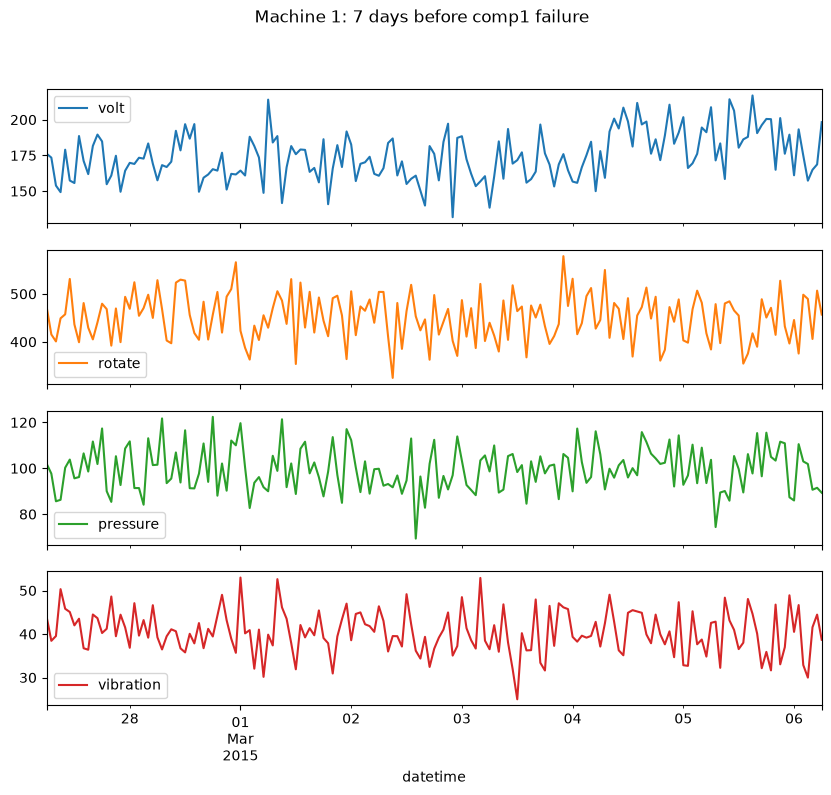

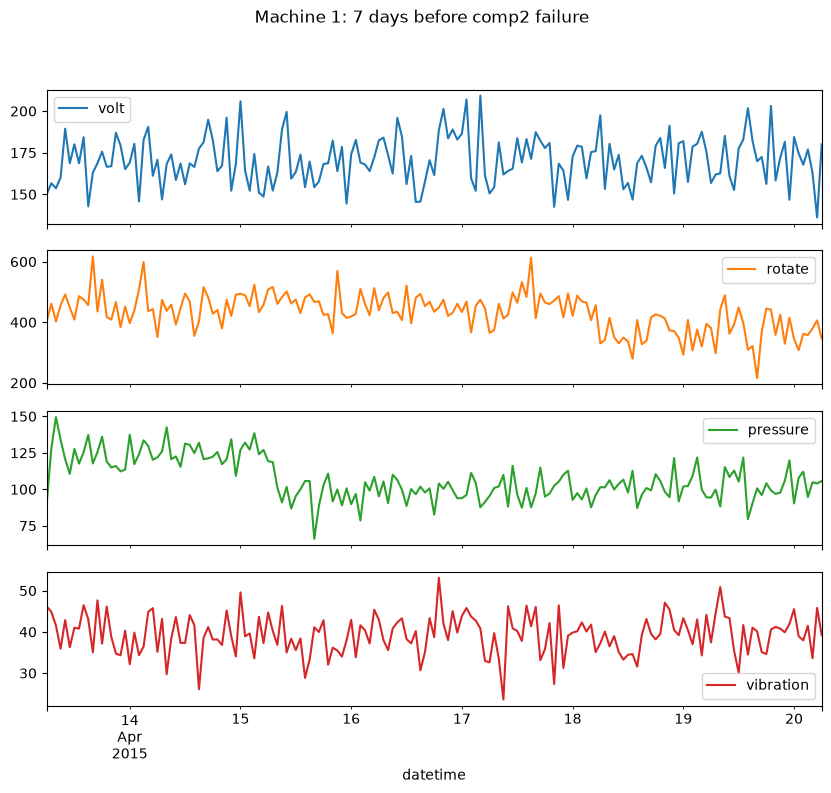

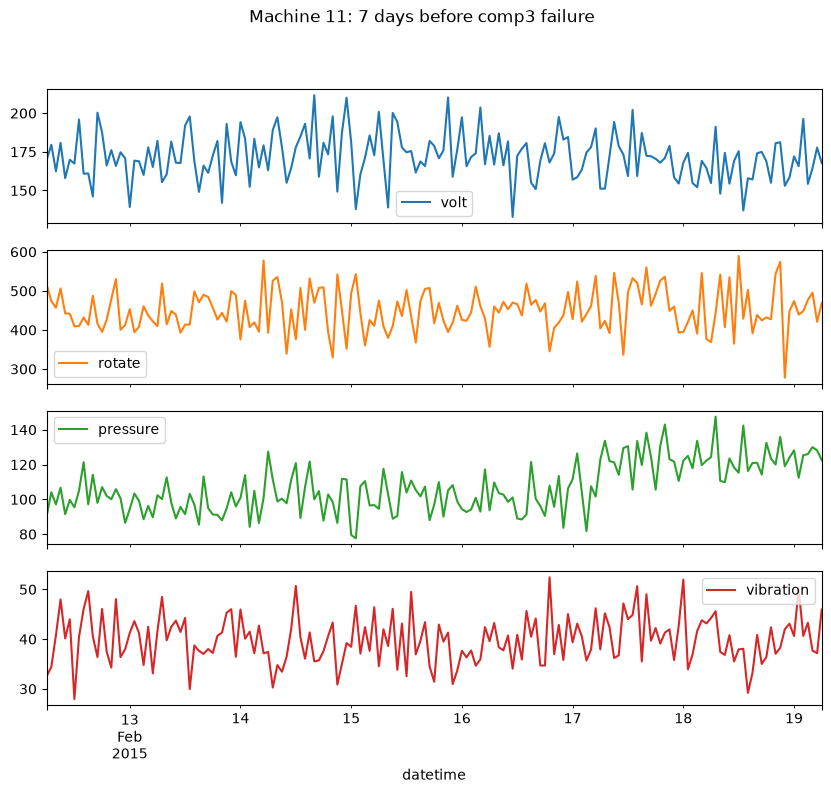

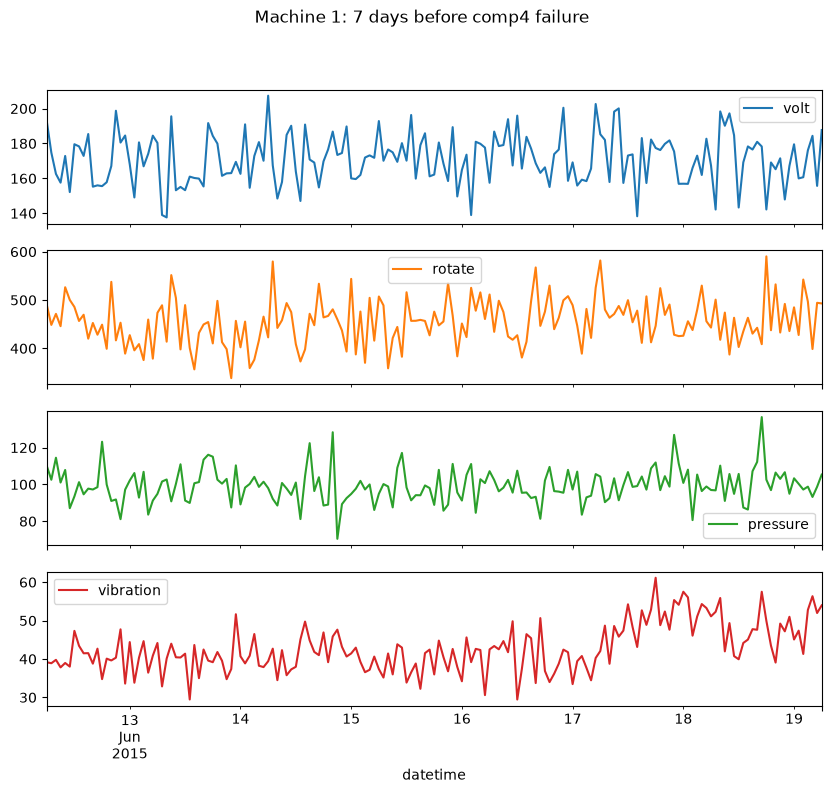

In [43]:
# Skip the first week of 2015 so every window has a full 7 days of sensor data
full_history = fail[fail["datetime"] >= "2015-01-08"]

for comp in ["comp1", "comp2", "comp3", "comp4"]:
    f = full_history[full_history["failure"] == comp].iloc[0]      # first such failure
    window = tel[(tel["machineID"] == f["machineID"]) &
                 (tel["datetime"].between(f["datetime"] - pd.Timedelta(days=7), f["datetime"]))]

    window.set_index("datetime")[SENSORS].plot(
        subplots=True, figsize=(10, 8),
        title=f"Machine {f['machineID']}: 7 days before {comp} failure")
    plt.show()

In [44]:
tel_by_machine = dict(tuple(tel.groupby("machineID")))     # one small table per machine

rows = []
for _, f in fail.iterrows():
    t = tel_by_machine[f["machineID"]]
    last_24h = t[(t["datetime"] > f["datetime"] - pd.Timedelta(hours=24)) &
                 (t["datetime"] <= f["datetime"])]
    rows.append({"failure": f["failure"], **last_24h[SENSORS].mean().to_dict()})

before = pd.DataFrame(rows).groupby("failure").mean()
normal_mean, normal_std = tel[SENSORS].mean(), tel[SENSORS].std()

print(((before - normal_mean) / normal_std).round(2))

         volt  rotate  pressure  vibration
failure                                   
comp1    1.30   -0.07      0.07       0.03
comp2    0.02   -1.48      0.06       0.08
comp3    0.05   -0.06      2.23       0.01
comp4    0.00   -0.09      0.03       1.86


In [45]:
def shift_table(start_h, end_h):
    """Sensor shift (in std) in the window from end_h to start_h hours before each failure."""
    rows = []
    for _, f in fail.iterrows():
        t = tel_by_machine[f["machineID"]]
        w = t[(t["datetime"] > f["datetime"] - pd.Timedelta(hours=end_h)) &
              (t["datetime"] <= f["datetime"] - pd.Timedelta(hours=start_h))]
        rows.append({"failure": f["failure"], **w[SENSORS].mean().to_dict()})
    b = pd.DataFrame(rows).groupby("failure").mean()
    return ((b - normal_mean) / normal_std).round(2)

for start_h, end_h in [(0, 24), (24, 48), (48, 72), (72, 96)]:
    print(f"\n--- {start_h} to {end_h} hours before failure ---")
    print(shift_table(start_h, end_h))


--- 0 to 24 hours before failure ---
         volt  rotate  pressure  vibration
failure                                   
comp1    1.30   -0.07      0.07       0.03
comp2    0.02   -1.48      0.06       0.08
comp3    0.05   -0.06      2.23       0.01
comp4    0.00   -0.09      0.03       1.86

--- 24 to 48 hours before failure ---
         volt  rotate  pressure  vibration
failure                                   
comp1    1.30   -0.08     -0.00       0.00
comp2    0.03   -1.49      0.06       0.09
comp3    0.03   -0.04      2.31       0.03
comp4    0.02   -0.12      0.05       1.88

--- 48 to 72 hours before failure ---
         volt  rotate  pressure  vibration
failure                                   
comp1    0.04   -0.01     -0.03      -0.05
comp2    0.01   -0.04      0.00       0.00
comp3   -0.01    0.04      0.14      -0.00
comp4   -0.02    0.01     -0.04       0.05

--- 72 to 96 hours before failure ---
         volt  rotate  pressure  vibration
failure                     